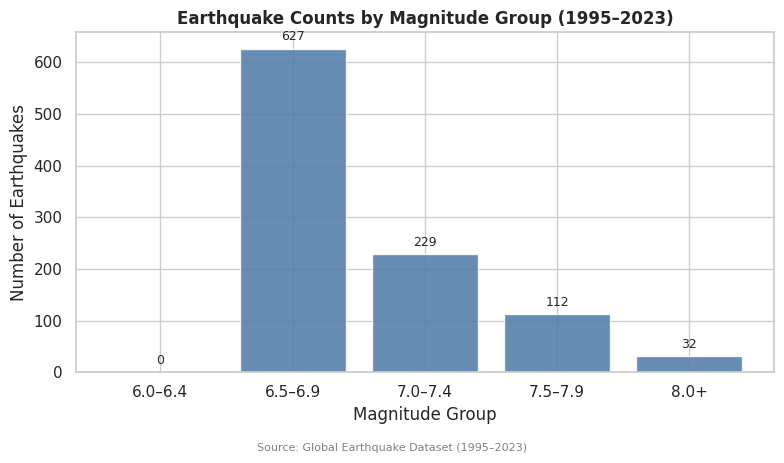

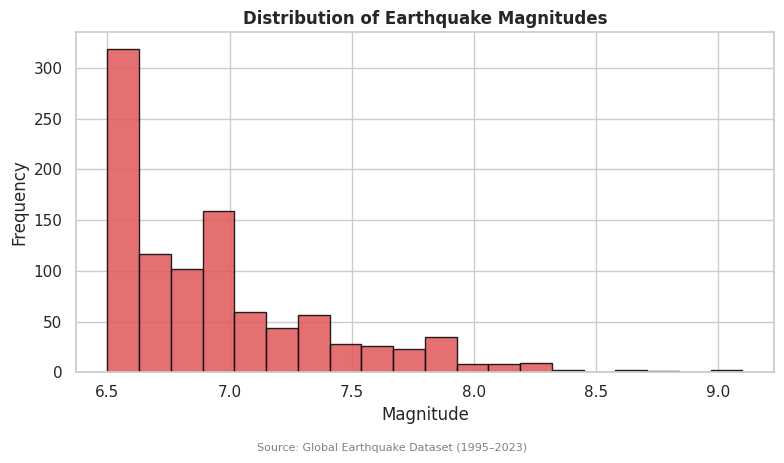

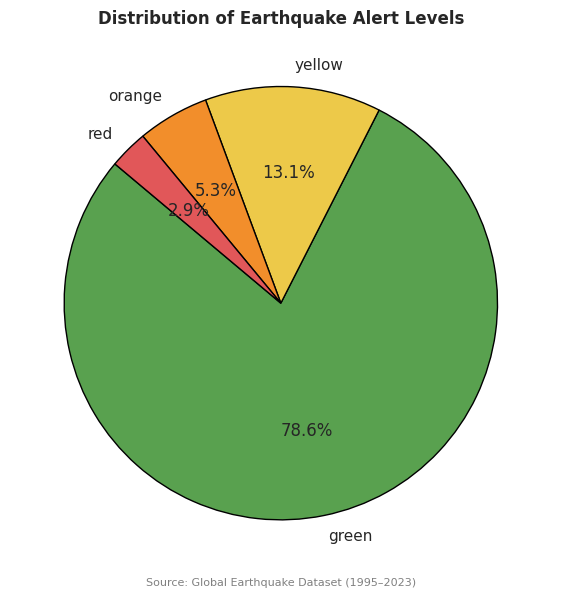

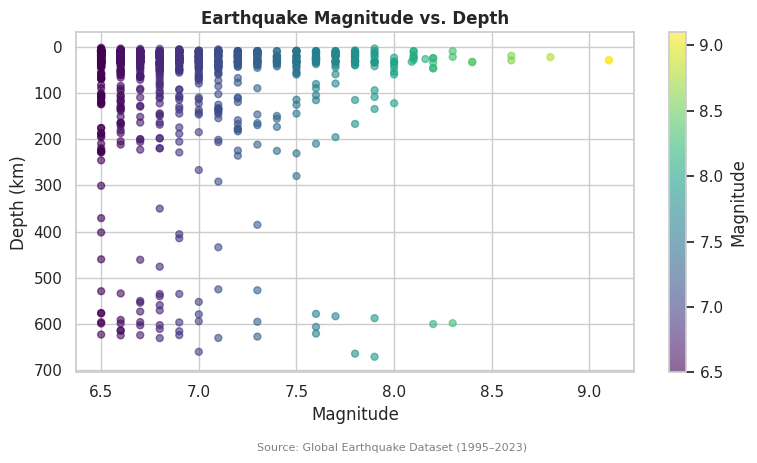

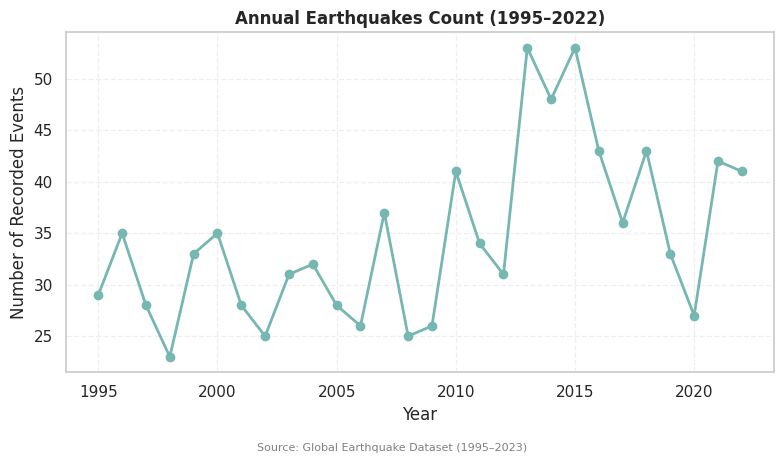

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('earthquake_1995-2023.csv')

# Categorize magnitude bands
bins = [6.0, 6.5, 7.0, 7.5, 8.0, 10.0]
labels = ['6.0–6.4', '6.5–6.9', '7.0–7.4', '7.5–7.9', '8.0+']
df['mag_group'] = pd.cut(df['magnitude'], bins=bins, labels=labels, right=False)
mag_counts = df['mag_group'].value_counts().sort_index()

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(mag_counts.index, mag_counts.values, color='#4e79a7', edgecolor='white', alpha=0.85)

ax.set_ylim(bottom=0)
ax.set_title('Earthquake Counts by Magnitude Group (1995–2023)', fontweight='bold')
ax.set_xlabel('Magnitude Group')
ax.set_ylabel('Number of Earthquakes')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10, f'{int(height):,}', ha='center', va='bottom', fontsize=9)

fig.text(0.5, -0.02, 'Source: Global Earthquake Dataset (1995–2023)', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df['magnitude'].dropna(), bins=20, color='#e15759', edgecolor='black', alpha=0.85)

ax.set_title('Distribution of Earthquake Magnitudes', fontweight='bold')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Frequency')

fig.text(0.5, -0.02, 'Source: Global Earthquake Dataset (1995–2023)', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()
alert_counts = df['alert'].dropna().value_counts()

colors = {'green': '#59a14f', 'yellow': '#edc949', 'orange': '#f28e2b', 'red': '#e15759'}
pie_colors = [colors.get(c, '#76b7b2') for c in alert_counts.index]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    alert_counts.values,
    labels=alert_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=pie_colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

ax.set_title('Distribution of Earthquake Alert Levels', fontweight='bold')
fig.text(0.5, 0.01, 'Source: Global Earthquake Dataset (1995–2023)', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(8, 4.5))
scatter = ax.scatter(
    df['magnitude'],
    df['depth'],
    c=df['magnitude'],
    cmap='viridis',
    alpha=0.6,
    s=25
)

ax.set_title('Earthquake Magnitude vs. Depth', fontweight='bold')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Depth (km)')
ax.invert_yaxis()  # Invert so deeper events plot further down

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Magnitude')

fig.text(0.5, -0.02, 'Source: Global Earthquake Dataset (1995–2023)', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()
df['year'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M', errors='coerce').dt.year
yearly_counts = df.groupby('year').size().loc[1995:2022]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(yearly_counts.index, yearly_counts.values, marker='o', color='#76b7b2', linewidth=2)

ax.set_title('Annual Earthquakes Count (1995–2022)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Recorded Events')
ax.grid(True, linestyle='--', alpha=0.3)

fig.text(0.5, -0.02, 'Source: Global Earthquake Dataset (1995–2023)', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()